NumPy简介4 - Reduction 与数组重组
==============

# 第十章：Reduction 与 Axis

<details>
<summary>查看解释</summary>

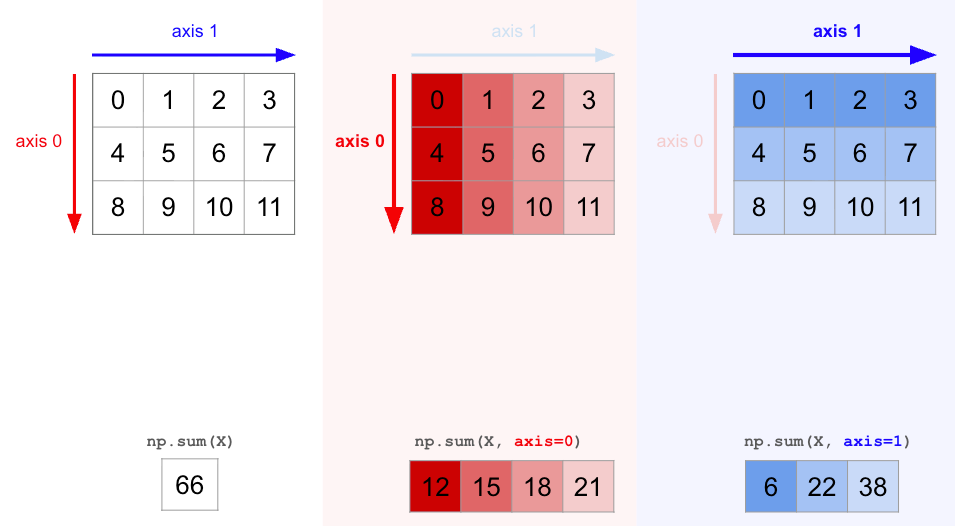
</details>

In [ ]:
X = np.arange(12).reshape(3, 4)
print(X)

In [ ]:
np.sum(X)            # X 中所有元素加和

In [ ]:
np.sum(X, axis=0)    # 每列单独加和

In [ ]:
np.sum(X, axis=1)    # 每行单独加和

## 10.2 keepdims：保留维度，便于后续广播

In [ ]:
X = np.random.rand(2, 3, 4, 5)
sum = np.sum(X, axis=(2,3), keepdims=True)
print(f"{X.shape=}\n{sum.shape=}")

In [ ]:
X / sum

## 10.3 常见 reduction：mean / std / max / argmax

In [ ]:
np.mean(X, axis=0)  # 每列求平均

In [ ]:
np.std(X, axis=0)  # 每列的标准差

In [ ]:
np.max(X, axis=1)  # 每行求最大值

In [ ]:
np.argmax(X, axis=1)  # 每行最大值的下标

## 10.4 高维 softmax 示例

**Softmax 函数**

Softmax 用于将一个向量映射为一个概率分布。

给定一个向量 $x = (x_1, x_2, \dots, x_n)$，softmax 定义为：

$$
\mathrm{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$$

**Softmax 的输出满足:**

- 每个元素都在 $(0, 1)$ 区间内
- 所有元素之和等于 1

In [ ]:
X = np.arange(2*3*4, dtype=np.float32).reshape(2, 3, 4) - 12
print(f"{X=}\n{X.shape=}")

In [ ]:
def softmax(X):
    expX = np.exp(X)                                # shape: (2, 3, 4)
    expXSum = np.sum(expX, axis=-1, keepdims=True)  # shape: (2, 3, 1)
    return expX / expXSum                           # shape: (2, 3, 4)

softmaxX = softmax(X)
print(softmax(X))

In [ ]:
# 验证：softmax最后一维求和应为全 1（形状: 2 x 3）
np.sum(softmaxX, axis=-1)

## 10.5 工程经验:
- 尽量避免 Python 层面的循环。
- 尽量使用 Numpy 中的批处理、向量化操作。
- 一般情况下，数值计算性能会大幅提升。

In [ ]:
# 手动循环版softmax
def softmax_using_loop(X):
    output = np.zeros_like(X, dtype=np.float32)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            x_slice = X[i, j, :]
            exp_x_slice = np.array([np.exp(val) for val in x_slice])
            sum_exp_x_slice = np.sum(exp_x_slice)
            softmax_slice = exp_x_slice / sum_exp_x_slice
            output[i, j, :] = softmax_slice
    return output

In [ ]:
X_large = np.random.rand(100, 100, 100).astype(np.float32)

# 批处理版softmax性能测试:
%timeit softmax(X_large)
# 循环版softmax性能测试：
%timeit softmax_using_loop(X_large)

# 第十一章：数组重组（concat / stack / split）

## 11.0 辅助函数（读取/展示图片与视频）

In [ ]:
import imageio
import io
import numpy as np
from IPython.display import display, Image as IPythonImage
from PIL import Image

def read_image(path="/content/drive/MyDrive/Colab Notebooks/Clark.jpg"):
    img = Image.open(path)
    img = np.asarray(img).copy()
    return img

def display_image(img_hwc_uint8):
    if img_hwc_uint8.dtype == np.bool:
        img_hwc_uint8 = img_hwc_uint8.astype(np.uint8) * 255
    img_hwc_uint8 = img_hwc_uint8.astype(np.uint8)
    display(Image.fromarray(img_hwc_uint8))

def display_video_as_gif(video, fps=10, loop=0):
    buf = io.BytesIO()
    imageio.mimsave(buf, video, format="gif", fps=fps, loop=loop)
    display(IPythonImage(data=buf.getvalue(), format="gif"))

In [ ]:
# read image:
img = read_image("/content/drive/MyDrive/Colab Notebooks/moon.png")
display_image(img)

# generating mask:
mask = np.mean(img, axis=2) > 50
display_image(mask)              # (H, W)

# optimize moon part:
img_f = img.astype(np.float32)   # (H, W, 3)

img_f[mask, 0] *= 0.8            # R
img_f[mask, 1] *= 1.0            # G
img_f[mask, 2] *= 1.5            # B

img = np.clip(img_f, 0, 255).astype(np.uint8)
display_image(img)

# crop moon:
v_mask = np.any(mask, axis=1)
h_mask = np.any(mask, axis=0)

img = img[v_mask][:, h_mask]     # (h_moon, w_moon, 3)
# img = img[np.ix_(v_mask, h_mask)]  # 也可以这样写

display_image(img)

In [ ]:
# 读取图片
img = read_image()
print('img shape:', img.shape, 'dtype:', img.dtype)
display_image(img)

## 11.1 np.concatenate：拼接（不增加维度）

核心直觉：
- `concatenate` 只会让某个 `axis` 方向变长 (拼接)
- 不会新增维度


### 11.1.1 图片横向拼接

In [ ]:
bright = np.clip(img + 80.0, 0, 255).astype(np.uint8)
dark   = np.clip(img - 80.0, 0, 255).astype(np.uint8)
high_c = np.clip((img - 128.0) * 1.5 + 128, 0, 255).astype(np.uint8)
low_c  = np.clip((img - 128.0) * 0.5 + 128, 0, 255).astype(np.uint8)


hcat = np.concatenate([img, bright, dark, high_c, low_c], axis=1)
display_image(hcat)


In [ ]:
frames = []

black = np.zeros((img.shape[0], img.shape[1]), dtype=img.dtype)  # (H, W)

for frame in [img, bright, dark, high_c, low_c]:
    # 用 stack 构造 R / G / B 单色图像
    R = np.stack([frame[:, :, 0], black, black], axis=2)  # (H, W) * 3 ⮕ (H, W, 3)
    G = np.stack([black, frame[:, :, 1], black], axis=2)  # (H, W) * 3 ⮕ (H, W, 3)
    B = np.stack([black, black, frame[:, :, 2]], axis=2)  # (H, W) * 3 ⮕ (H, W, 3)

    # 用 concatenate 将它们在水平方向拼接
    frame_hcat = np.concat([frame, R, G, B], axis=1)   # (H, W, 3) * 4 ⮕ (H, 4*W, 3)
    frames.append(frame_hcat)

# 在最外层，用 stack 组织成一个视频
video = np.stack(frames, axis=0)                     # (H, 4*W, 3) * N ⮕ (N, H, 4*W, 3)

display_video_as_gif(video, fps=1)


In [ ]:
img2 = 255 - img  # 取反色

# 黑色间隔条
spacer = np.zeros((img.shape[0], 16, img.shape[2]), dtype=img.dtype)

print('img    shape:', img.shape)
print('spacer shape:', spacer.shape)
print('img2   shape:', img2.shape)

In [ ]:
hcat = np.concatenate([img, spacer, img2], axis=1)
print('hcat shape:', hcat.shape)
display_image(hcat)

### 11.1.2 图片纵向拼接

In [ ]:
img3 = img // 2  # 图片变暗

# 白色间隔条（横条）
spacer_v = np.full((16, img.shape[1], img.shape[2]), 255, dtype=img.dtype)

print('img      shape:', img.shape)
print('spacer_v shape:', spacer_v.shape)
print('img3     shape:', img3.shape)

In [ ]:
vcat = np.concatenate([img, spacer_v, img3], axis=0)
print('vcat shape:', vcat.shape)
display_image(vcat)

### 11.1.3 concat 失败示例：除了拼接axis以外，其他维度必须一致

In [ ]:
try:
    bad = np.zeros((512, 800, 3), dtype=img.dtype)  # 与 (600, 800, 3) 在 axis!=1 处不匹配
    np.concatenate([img, bad], axis=1)
except ValueError as e:
    print('ValueError:', e)

### 11.1.4 concatenate 的一般规则
- 输入数组的 `ndim` 必须相同
- 除了 `axis` 指定维度外，其余维度必须完全一致
- 输出 `ndim` 不变，只有 `shape[axis]` 会变大


## 11.2 np.stack：新增一个维度再拼接

### 11.2.1 HW 灰度图 stack 成 HWC 图片

In [ ]:
H, W = 256, 256
light = np.full((H, W), 255, dtype=np.uint8)  # 亮色. Shape: (256, 256)
dark = np.zeros((H, W), dtype=np.uint8)       # 暗色. Shape: (256, 256)

red = np.stack([light, dark, dark], axis=2)   # 红色. Shape: (256, 256, 3)
print('red shape:', red.shape)
display_image(red)

### 11.2.2 多张 HWC 图片 stack 成 NHWC 视频

In [ ]:
green = np.stack([dark, light, dark], axis=2)               # (256, 256, 3)
blue  = np.stack([dark, dark, light], axis=2)               # (256, 256, 3)
white = np.stack([light, light, light], axis=2)             # (256, 256, 3)
black = np.zeros((H, W, 3), dtype=np.uint8)                 # (256, 256, 3)

video = np.stack([red, green, blue, white, black], axis=0)  # (5, 256, 256, 3)
print('video shape:', video.shape)
display_video_as_gif(video, fps=1, loop=0)

## 11.3 concatenate + stack 组合
做一个“左右对比”的小视频

In [ ]:
h, w = 128, 128
light_s = np.full((h, w), 255, dtype=np.uint8)
dark_s  = np.zeros((h, w), dtype=np.uint8)

red   = np.stack([light_s, dark_s,  dark_s], axis=2)         # (128, 128, 3)
blue  = np.stack([dark_s,  dark_s,  light_s], axis=2)        # (128, 128, 3)
green = np.stack([dark_s,  light_s, dark_s], axis=2)         # (128, 128, 3)
black = np.zeros((h, w, 3), dtype=np.uint8)                  # (128, 128, 3)

spacer = np.zeros((h, 8, 3), dtype=np.uint8)                 # (128, 8, 3)

frame1 = np.concatenate([red, spacer, blue], axis=1)         # (128, 264, 3)
frame2 = np.concatenate([black, spacer, green], axis=1)      # (128, 264, 3)
frame3 = np.concatenate([blue, spacer, red], axis=1)         # (128, 264, 3)

video2 = np.stack([frame1, frame2, frame3, frame2], axis=0)  # (4, 128, 264, 3)
print('video2 shape:', video2.shape)
display_video_as_gif(video2, fps=1, loop=0)

## 11.4 split：拆分数组

### 11.4.1 按切点分

In [ ]:
H, W, C = img.shape
i1 = 100
i2 = 250

p1, p2, p3 = np.split(img, [i1, i2], axis=0)
print('p1:', p1.shape)  # img[:i1,   ...]
display_image(p1)
print('p2:', p2.shape)  # img[i1:i2, ...]
display_image(p2)
print('p3:', p3.shape)  # img[i2:,   ...]
display_image(p3)

### 11.4.2 等分成 N 份

In [ ]:
try:
    parts = np.split(img, 4, axis=0)
    for i, p in enumerate(parts):
        print(f'parts[{i}] shape:', p.shape)
        display_image(p)
except ValueError as e:
    print('ValueError:', e)
    print('提示：np.split(x, 4, axis=0) 要求 x.shape[0] 能被 4 整除。')

## 11.5 其他常用“组合函数”（了解即可）

| 函数                             | 作用（简写说明）                             |
| ------------------------------ | ------------------------------------ |
| **`array_split`**              | 拆分数组（不要求整除）；`split` 的宽容版本            |
| **`hsplit` / `vsplit` / `dsplit`**       | 沿 `axis=1 / 0 / 2` 拆分；`split` 的固定轴写法 |
| **`hstack` / `vstack` / `dstack`**   | 沿列 / 行 / 深度拼接；拼接类函数的快捷写法             |
| **`column_stack` / `row_stack`**   | 将 1D 数组按列 / 行拼成 2D                   |
| **`block`**                    | 按“积木布局”拼数组；可读性高的多次拼接                 |
| **`tile` / `repeat`**                   | 复制并扩展数组；`tile` 复制整体结构，`repeat` 复制元素 |
| **`unstack`**                  | NumPy 无原生接口；通常用 `split` 或索引实现        |


## 11.6 总结

- 拼但不加维度 → `concatenate`
- 拼且要加维度 → `stack`
- 一个变多个 → `split`
- 更多操作 → 查询 API
